In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import copy
import numpy as np
import seaborn as sns
from scipy import stats
%matplotlib inline

from pathlib import Path

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

# Functions

In [2]:
def fastq_to_dataframe(fastq_file):
    sequences = []

    # Open the FASTQ file
    with open(fastq_file, 'r') as file:
        # Read the file line by line
        lines = file.readlines()

        # Iterate over the lines starting from the second line, taking every fourth line
        for i in range(1, len(lines), 4):
            sequence = lines[i].strip()  # Remove any leading/trailing whitespace
            sequences.append(sequence)

    # Create a Pandas DataFrame with the sequences
    df = pd.DataFrame({'Sequence': sequences})
    return df

def process_aa_variant(row):
    aa_variant = str(row['variant'])
    try:
        if 'fs' in aa_variant:
            if len(aa_variant) in [4, 5, 6]:
                wild_type_residue = aa_variant[1]
                mutation = 'frame shift'
                if len(aa_variant) == 4:
                    position = int(aa_variant[1])
                    return wild_type_residue, mutation, position
                elif len(aa_variant) == 5:
                    position = int(aa_variant[1:3])
                    return wild_type_residue, mutation, position
                elif len(aa_variant) == 6:
                    position = int(aa_variant[1:4])
                    return wild_type_residue, mutation, position
        elif '|' in aa_variant:
            return 'unknown', 'unknown', 'unknown'
        elif 'RT' in aa_variant:
            return 'unknown', 'unknown', 'unknown'
        elif 'silent' in aa_variant:
            return 'unknown', 'unknown', 'unknown'
        elif 'WT' in aa_variant:
            return 'wild type', 'wild type', 'wild type'
        elif '_wt' in aa_variant:
            return 'wild type', 'wild type', 'wild type'
        elif 'std' in aa_variant:
            return 'standard', 'standard', 'standard'
        else:
            if len(aa_variant) in [3, 4, 5, 6]:
                wild_type_residue = aa_variant[0]
                mutation = aa_variant[-1]
                if len(aa_variant) == 3:
                    position = int(aa_variant[1])
                    return wild_type_residue, mutation, position
                elif len(aa_variant) == 4:
                    position = int(aa_variant[1:3])
                    return wild_type_residue, mutation, position
                elif len(aa_variant) == 5:
                    position = int(aa_variant[1:4])
                    return wild_type_residue, mutation, position
                elif len(aa_variant) == 6:
                    position = int(aa_variant[1:5])
                    return wild_type_residue, mutation, position
            else:
                return 'unknown', 'unknown', 'unknown'
    except Exception as e:
        print(f"Error processing aa_variant: {aa_variant}")
        print(f"Exception: {e}")
        return 'unknown'

# Define function to generate the label
def generate_label(row):
    if row['Wild Type Residue'] == 'wild type':
        return 'wild type'
    elif row['Wild Type Residue'] == 'unknown':
        return 'unknown'
    else:
        return str(row['Wild Type Residue']) + str(row['Position']) + str(row['Mutation'])

def safe_process_aa_variant(row):
    try:
        return process_aa_variant(row)
    except Exception as e:
        print(f"Error processing aa_variant: {row['variant']}")
        return None, None, None

# Define function to identify mutation type
def mutation_type(row):
    if row['Wild Type Residue'] == 'wild type':
        return 'wild type'
    elif row['Mutation'] == 'unknown':
        return 'unknown'
    elif row['Mutation'] == 'standard':
        return 'standard'
    elif row['Wild Type Residue'] == row['Mutation']:
        return 'synonymous wild type'
    elif row['Mutation'] == 'frame shift':
        return 'frame shift'
    elif row['Mutation'] == '-':
        return 'deletion'
    elif row['Mutation'] == '*':
        return 'nonsense'
    else:
        return 'missense'

def convert_AA_abbreviation(heatmap_data):
    for i, row in heatmap_data.iterrows():
        if row['Mutation'] == 'Arg':
            heatmap_data.at[i, 'Mutation'] = 'R'
        elif row['Mutation'] == 'His':
            heatmap_data.at[i, 'Mutation'] = 'H'
        elif row['Mutation'] == 'Lys':
            heatmap_data.at[i, 'Mutation'] = 'K'
        elif row['Mutation'] == 'Asp':
            heatmap_data.at[i, 'Mutation'] = 'D'
        elif row['Mutation'] == 'Glu':
            heatmap_data.at[i, 'Mutation'] = 'E'
        elif row['Mutation'] == 'Ser':
            heatmap_data.at[i, 'Mutation'] = 'S'
        elif row['Mutation'] == 'Thr':
            heatmap_data.at[i, 'Mutation'] = 'T'
        elif row['Mutation'] == 'Asn':
            heatmap_data.at[i, 'Mutation'] = 'N'
        elif row['Mutation'] == 'Gln':
            heatmap_data.at[i, 'Mutation'] = 'Q'
        elif row['Mutation'] == 'Cys':
            heatmap_data.at[i, 'Mutation'] = 'C'
        elif row['Mutation'] == 'Gly':
            heatmap_data.at[i, 'Mutation'] = 'G'
        elif row['Mutation'] == 'Pro':
            heatmap_data.at[i, 'Mutation'] = 'P'
        elif row['Mutation'] == 'Ala':
            heatmap_data.at[i, 'Mutation'] = 'A'
        elif row['Mutation'] == 'Val':
            heatmap_data.at[i, 'Mutation'] = 'V'
        elif row['Mutation'] == 'Ile':
            heatmap_data.at[i, 'Mutation'] = 'I'
        elif row['Mutation'] == 'Leu':
            heatmap_data.at[i, 'Mutation'] = 'L'
        elif row['Mutation'] == 'Met':
            heatmap_data.at[i, 'Mutation'] = 'M'
        elif row['Mutation'] == 'Phe':
            heatmap_data.at[i, 'Mutation'] = 'F'
        elif row['Mutation'] == 'Tyr':
            heatmap_data.at[i, 'Mutation'] = 'Y'
        elif row['Mutation'] == 'Trp':
            heatmap_data.at[i, 'Mutation'] = 'W'
        elif row['Mutation'] == 'Ter':
            heatmap_data.at[i, 'Mutation'] = '*'
    return heatmap_data

In [3]:
def heatmap_from_ReplicateScores(metric, minimum, maximum, center, title, scale, firstPosition, lastPosition):
    sns.set(font_scale=1.6)

    #Change mutation to single letter abbreviations
    heatmap_data = Replicate_scores.copy()
    heatmap_data = convert_AA_abbreviation(heatmap_data)
    
    #Remove standards and position 1, neither of which have scores
    heatmap_data = heatmap_data[(heatmap_data['Mutation'] != 'standard') 
                                #& (heatmap_data['Position'] != 1)
                               ]
    # Convert Position column to numeric, setting errors='coerce' to turn non-numeric values into NaN
    heatmap_data['Position'] = pd.to_numeric(heatmap_data['Position'], errors='coerce')

    # Drop rows where Position is NaN (due to non-numeric values) before converting to int
    heatmap_data = heatmap_data.dropna(subset=['Position'])

    # Now safely convert Position to integer type
    heatmap_data['Position'] = heatmap_data['Position'].astype(int)
    
    heatmap_data = heatmap_data[heatmap_data['Position'] > (firstPosition-1)]
    heatmap_data = heatmap_data[heatmap_data['Position'] < (lastPosition+1)]
    
    #remove wild type data
    heatmap_data = heatmap_data[(heatmap_data['Mutation'] != 'synonymous') & (heatmap_data['Mutation'] != 'wild type') & (heatmap_data['Mutation'] != 'unknown')]
    
    if scale == 'log2':
        #calculate log2 score
        heatmap_data['log2_score'] = np.log2(heatmap_data[metric])
    
        #restructure it to be in the correct form for a heatmap. Each value is the average ratio for that mutation
        #at that position
        heatmap_data= heatmap_data.groupby(['Position', 'Mutation'])['log2_score'].mean().unstack()
    elif scale == 'linear':
        heatmap_data= heatmap_data.groupby(['Position', 'Mutation'])[metric].mean().unstack()

    #transpose data so ORF position is on the x-axis
    heatmap_data= heatmap_data.transpose()

    orders = ['R' ,'K', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'C', 'G', 'P', 'A', 'V', 'I', 'L', 'M', 'F', 'Y', 'W', '*', '-']

    plt.figure(figsize = (80,10))

    # Reindex data
    reindexed_data = heatmap_data.reindex(orders, axis=0)

    # Plot data with colormap
    cmap_data = plt.cm.RdBu_r

    ax = sns.heatmap(reindexed_data, cmap=cmap_data, 
                     vmin=minimum, vmax=maximum, 
                     center=center)

    plt.title(title, fontsize = 30)
    plt.xlabel('Position', fontsize = 40, fontname='Sans Serif')
    plt.ylabel('Mutation', fontsize = 40, fontname='Sans Serif')
    plt.yticks(rotation=0)
    plt.xticks(rotation=90)

    plt.title(title, fontsize = 40)

    # Make tick labels bold
    for label in plt.gca().get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontname('Sans Serif')

    for label in plt.gca().get_xticklabels():
        label.set_fontweight('bold')
        label.set_fontname('Sans Serif')

    plt.tick_params(left=False, bottom=True) ## other options are right and top

# Generate dataframes

In [4]:
### Insert parameters here ###

# data_storage_path: Path to storage location where plots generated by this code will be saved
# barcode_AAvar_map: Path to pacybara output file. Requires columns named 'barcode', 'collision', 'aaChanges'
# standards_barcode_AAvar_map: Tsv file containing indicating barcode sequences beloning to each standard. Barcodes for each standard should be listed in separate columns
# count_cutoff: minimum number of reads required for a barcoded to be included in any analysis
# mean_barcodes_cutoff: For any given variant, the mean number of barcodes that need to be quantified per replicate. A quantified barcode is one that surpassess the count_cutoff in both the Flag and HT enrichments
# freq_cutoffs: The minimum frequency that a barcode must surpass to be included in any analysis
# path: Path to paried fastq files
# enrichment: Enrichment type, one string per enrichment
# replicate: Strings, need to be ordered the same as your enrichments
# number: Sample number that PEAR associates with each amplicon on the sample sheet
# files: File names generated by PEAR, used to generate path to the data

experiment_name = '260230_BRaf_cterm_abundance_SJF0661'
library = 'BRAF_cterm'
data_storage_path = '/Users/oliviaweissenfels/desktop/BRAF-PROTAC-mutational-scanning-labelseq/analysis/abundance_cterm/SJF0661_BRaf-Cterm-abun/'
barcode_AAvar_map = pd.read_csv('/Users/oliviaweissenfels/desktop/BRAF-PROTAC-mutational-scanning-labelseq/data/barcode_maps/BRAFcterm_abu.csv')
standards_barcode_AAvar_map = pd.read_csv('/Users/oliviaweissenfels/desktop/BRAF-PROTAC-mutational-scanning-labelseq/data/barcode_maps/Abundance Standard Curve Barcodes_2.tsv', sep='\t')
count_cutoff = 10
mean_barcodes_cutoff = 5
freq_cutoffs = [0,0]

# Where to find fastq files and their names
path = '/Users/oliviaweissenfels/desktop/BRAF-PROTAC-mutational-scanning-labelseq/data/processed/braf-cterm-abu_fastqs/'

enrichment = ['Flag', 'Flag', 'HT', 'HT']
replicate = ['1', '2', '1', '2']
number = ['25', '26', '27', '28']
files = [f"SJF0661_{enrich}_{rep}_S{i}/SJF0661_{enrich}_{rep}_S{i}.assembled.fastq" for enrich, rep, i in zip(enrichment, replicate, number)]


In [5]:
# creates new directories to store your data, if they doesn't already exist
subfolder_path = data_storage_path+'pymol_files'
subfolder_path2 = data_storage_path+'plots'
Path(subfolder_path).mkdir(parents=True, exist_ok=True)
Path(subfolder_path2).mkdir(parents=True, exist_ok=True) 

file_paths = [path + file_name for file_name in files]
sample_names = [f"{enrich}_{rep}" for enrich, rep in zip(enrichment, replicate)]


In [6]:
# Create a dictionary to store the dataframes
dfs = {}

# Apply the fastq_to_dataframe function to each file path
for file_path, sample_name in zip(file_paths, sample_names):
    # Print update
    print('Starting ' + sample_name + ' dataframe')
    # Generate a dataframe for each file path and store it with the corresponding sample name
    dfs[sample_name] = fastq_to_dataframe(file_path)
    # Print update
    print('Created ' + sample_name + ' dataframe')
    
# Create an empty dictionary to store DataFrames containing the unqiue sequences and their counts for each sample
unique_dfs = {}

# Iterate over each sample and its corresponding DataFrame
for sample_name, df in dfs.items():
    # Count the occurrences of each unique sequence
    unique_sequences_df = df['Sequence'].value_counts().reset_index()  
    
    # Filter sequences with count > 2
    unique_sequences_df = unique_sequences_df[unique_sequences_df['count'] > 2]

    # Rename columns
    unique_sequences_df = unique_sequences_df.rename(columns={"count": sample_name })

    # Store the result in the unique_dfs dictionary
    unique_dfs[sample_name] = unique_sequences_df

    # Print update
    print('Counted ' + sample_name + ' dataframe and added to unique_dfs dictionary')
    
# Create 'data' DataFrame
merged_data = pd.DataFrame()
merged_data['Sequence'] = []

# Iterate over each DataFrame in unique_dfs and merge it with 'data'
for df in unique_dfs.values():
    # Merge the current DataFrame with 'data' based on the 'sequence' column
    merged_data = pd.merge(merged_data, df, on='Sequence', how='outer')
    
merged_data.to_csv(data_storage_path + 'mergeddata.tsv', sep='\t')

merged_data = pd.read_csv(data_storage_path + 'mergeddata.tsv', sep='\t').drop(columns={'Unnamed: 0'})

Starting Flag_1 dataframe
Created Flag_1 dataframe
Starting Flag_2 dataframe
Created Flag_2 dataframe
Starting HT_1 dataframe
Created HT_1 dataframe
Starting HT_2 dataframe
Created HT_2 dataframe
Counted Flag_1 dataframe and added to unique_dfs dictionary
Counted Flag_2 dataframe and added to unique_dfs dictionary
Counted HT_1 dataframe and added to unique_dfs dictionary
Counted HT_2 dataframe and added to unique_dfs dictionary


In [7]:
#Merge AAvar map ('barcode_AAvar_map') with Illumina counted barcodes and calculated ratios into single dataframe

# Change barcode to reverse complement
barcode_AAvar_map['RevComplement'] =''

for i,row in barcode_AAvar_map.iterrows():
    seq = str(row['virtualBarcode'])
    newseq = seq.replace("A", "t").replace("C", "g").replace("T", "a").replace("G", "c")
    newseq = newseq.upper() #change replaced letters to uppercase
    newseq = newseq[::-1]  #reverse strand
    barcode_AAvar_map.at[i, 'RevComplement'] = newseq
    
# # Add standard curve variants
std_curve_vars = standards_barcode_AAvar_map.melt(var_name='aaChanges', value_name='RevComplement').dropna() # transform dataframe
barcode_AAvar_map = pd.concat([barcode_AAvar_map, std_curve_vars], ignore_index=True).dropna(subset=['RevComplement'])

# Merge data with barcode_AAvar_map
data_beforefreqcutoff = pd.merge(barcode_AAvar_map.set_index('RevComplement'), merged_data.set_index('Sequence'), left_index=True, right_index=True).reset_index()
    
data_beforefreqcutoff = data_beforefreqcutoff[['RevComplement', 'collision', 'aaChanges', 'Flag_1', 'Flag_2', 'HT_1', 'HT_2']].rename(columns={"aaChanges":"variant", "RevComplement":"barcode"})

data_beforefreqcutoff.to_csv(data_storage_path + '/dataframe_beforefreqcutoff.tsv', sep='\t', index=False)

data_beforefreqcutoff = pd.read_csv(data_storage_path + '/dataframe_beforefreqcutoff.tsv', sep='\t')


In [8]:
data = data_beforefreqcutoff.copy()
#data = data[data['collision'] != 'collision']

# Labeling WT, mutation, position
data[['Wild Type Residue', 'Mutation', 'Position']] = data.apply(process_aa_variant, axis=1, result_type='expand')

#Count number of barcodes observed per variant 
data['Number of Barcodes'] = data['variant'].map(data['variant'].value_counts())

#Classify mutation type
data['Mutation Type'] = data.apply(mutation_type, axis=1)

# Institute count cutoff values
for j in range (1,3):
    data[f'Flag_{j}'] = np.where(data[f'Flag_{j}'] < count_cutoff, np.nan, data[f'Flag_{j}'])
    data[f'HT_{j}'] = np.where(data[f'HT_{j}'] < count_cutoff, np.nan, data[f'HT_{j}'])

# Calculate barcode frequency value then institute frequency cutoffs and apply the condition: If frequency_Flag_1 < cutoff_Flag_1, remove the value from Flag_1 (set to NaN)
replicates = ['1', '2']
for value, j in zip(freq_cutoffs, range(1, 3)):
        data[f'frequency_{j}'] = (data[f'Flag_{j}'] + data[f'HT_{j}'])/(data[f'Flag_{j}'].sum() + data[f'HT_{j}'].sum())
        data[f'Flag_{j}'] = np.where(data[f'frequency_{j}'] < value, np.nan, data[f'Flag_{j}'])

# Calculate ratios
for j in range (1,3):
    data[f'ratio_{j}'] = data[f'Flag_{j}']/data[f'HT_{j}']
    
#Calculate average barcode ratio, needed for standard curve generation
data['average ratio'] = (data['ratio_1'] + data['ratio_2'])/2

# Normalize to wild type
wt = data.reset_index()
wt = wt[wt['Mutation Type'] == 'synonymous wild type']    
for j in range (1,3):
    wt[f'ratio_{j}'] = wt[f'Flag_{j}']/wt[f'HT_{j}']
    wt_score = wt[f'ratio_{j}'].mean()
    data[f'score_{j}'] = (data[f'Flag_{j}']/data[f'HT_{j}'])/wt_score



In [9]:
# Calculate variant scores
Replicate_scores = data.groupby(['variant'])[['Number of Barcodes', 'average ratio', 'score_1', 'score_2']].mean().reset_index()
Replicate_scores['average score'] = (Replicate_scores['score_1']+Replicate_scores['score_2'])/2

# Re-assign wild type residue, mutation, and position
Replicate_scores[['Wild Type Residue', 'Mutation', 'Position']] = Replicate_scores.apply(process_aa_variant, axis=1, result_type='expand')
Replicate_scores['Mutation Type'] = Replicate_scores.apply(mutation_type, axis=1)
Replicate_scores = Replicate_scores[(Replicate_scores['Mutation Type'] != 'unknown')&(Replicate_scores['Mutation Type'] != 'frame shift')]

# Generate standard curve
standard_scores = Replicate_scores[Replicate_scores['Mutation Type'] == 'standard'].copy() #Best practice to explicitly state that you want a copy of the dataframe. Otherwise you could end up with a view and that's not what you want!
standard_scores['Assigned Standard Score'] = np.nan
assigned_score_dict = {'E695*_std':0.16, 'I592S_std':0.29, 'G258N_std':0.53, 'P367N_std':0.71, 'Wild Type_std':1}

for i,row in standard_scores.iterrows():
    variant = row['variant']
    if variant in assigned_score_dict:
        standard_scores.loc[i, 'Assigned Standard Score'] = assigned_score_dict[variant]
standard_scores['Assigned Standard Score'] = pd.to_numeric(standard_scores['Assigned Standard Score'], errors='coerce') #This line is necessary to get the polyfit below to run

standard_scores = standard_scores.dropna(subset=['Assigned Standard Score', 'average ratio']) #onw added to fix NaN problem in the std adj score column

slope, intercept, r_value, p_value, std_err = stats.linregress(standard_scores['Assigned Standard Score'].values, standard_scores['average ratio'].values)
rsquared = r_value**2

# Calculate adjusted variant scores
Replicate_scores['standard-adjusted score'] = (Replicate_scores['average ratio'] - intercept)/slope

# Count number of barcodes quantified in any given replicate and average number quantified
Replicate_scores_counts = data.groupby('variant')[[f'score_{j}' for j in range(1, 3)]].count().reset_index()
Replicate_scores_counts['average_num_quant_bc'] = (Replicate_scores_counts['score_1']+Replicate_scores_counts['score_2'])/2
Replicate_scores = Replicate_scores.merge(Replicate_scores_counts[['variant', 'average_num_quant_bc']], on='variant')

# Set minimum number of barcodes cutoff
Replicate_scores = Replicate_scores[Replicate_scores['average_num_quant_bc'] > mean_barcodes_cutoff]

# Save scores
Replicate_scores.to_csv(data_storage_path + experiment_name + '_Replicate_scores.tsv', sep='\t', index=False)

print('Number of observed variants (discarding non-programmed variants): ' + str(len(Replicate_scores)))


Number of observed variants (discarding non-programmed variants): 5281


In [10]:
Replicate_scores

,variant,Number of Barcodes,average ratio,score_1,score_2,average score,Wild Type Residue,Mutation,Position,Mutation Type,standard-adjusted score,average_num_quant_bc
1,A481A,20.0,0.583353,1.143921,1.232583,1.188252,A,A,481,synonymous wild type,0.584828,12.0
2,A481C,13.0,0.453362,0.954557,1.178880,1.066719,A,C,481,missense,0.341302,7.5
5,A481F,14.0,0.450768,1.012140,0.767514,0.889827,A,F,481,missense,0.336442,8.0
6,A481G,22.0,0.475102,0.980717,0.978966,0.979841,A,G,481,missense,0.382029,12.0
8,A481I,18.0,0.445940,1.122712,0.853729,0.988220,A,I,481,missense,0.327397,8.5
...,...,...,...,...,...,...,...,...,...,...,...,...
7329,Y760S,9.0,0.435710,0.900803,0.985325,0.943064,Y,S,760,missense,0.308233,5.5
7330,Y760T,16.0,0.463938,1.194821,0.785736,0.990278,Y,T,760,missense,0.361114,9.5
7331,Y760V,14.0,0.458730,1.028219,0.831080,0.929649,Y,V,760,missense,0.351358,8.5
7332,Y760W,15.0,0.582672,1.117652,1.170674,1.144163,Y,W,760,missense,0.583552,10.0


# Replicate counts and scores

r-squared = 0.2991


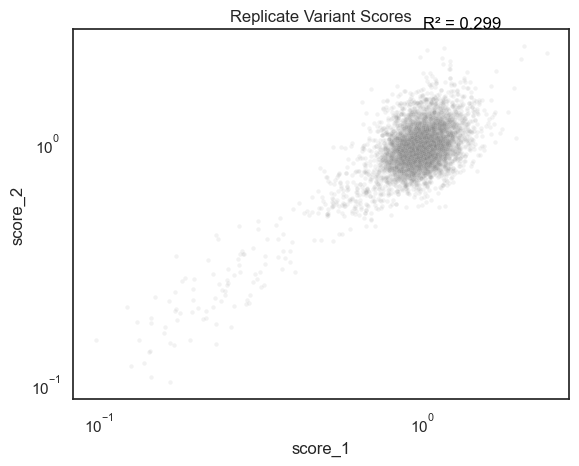

In [11]:
# Specify parameters here
sns.set(style='white')
          
subsets = Replicate_scores[Replicate_scores['Mutation Type'] != 'standard']

x = 'score_1'
y = 'score_2'

sns.scatterplot(data=subsets,
                    x=x, y=y, 
                    color="grey", s=10, alpha=0.1)
    
# Set title, labels and limits for each subplot
plt.title('Replicate Variant Scores')
# plt.xlim(-500, 7000)
# plt.ylim(-500, 7000)
plt.xscale('log')
plt.yscale('log')
    
# Linear regression statistics for each pair
select = subsets.dropna(subset=[x, y])
slope, intercept, r_value, p_value, std_err = stats.linregress(select[x], select[y])
rsquared = r_value**2
print(f"r-squared = {rsquared:.4f}")    
# print(f'{x} vs {y}: slope = {slope:.4f}, intercept = {intercept:.4f}, r-value = {r_value:.4f}, p-value = {p_value:.4f}')
    
# Add R² to the plot
plt.text(1, 3, f'R² = {rsquared:.3f}', fontsize=12, color='black')

# Save files
plt.savefig(data_storage_path + 'plots/' + experiment_name + '_replicate_variant_scores.svg')
plt.savefig(data_storage_path + 'plots/' + experiment_name + '_replicate_variant_scores.png')

r-squared = 0.8097


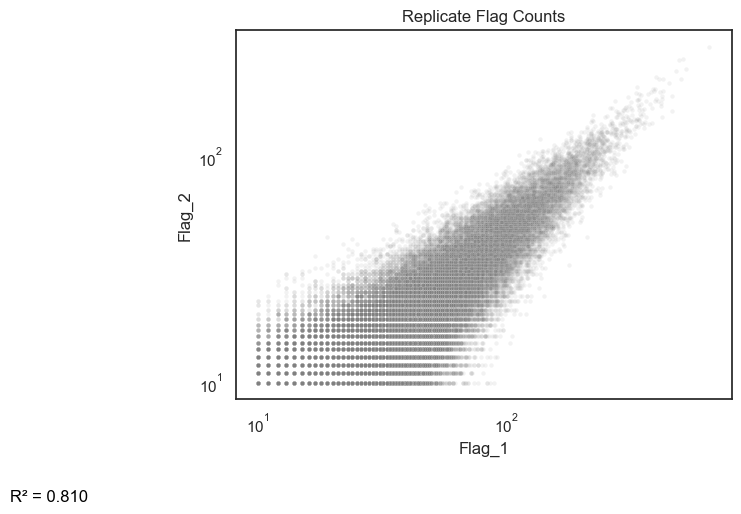

In [12]:
# Specify parameters here
sns.set(style='white')
          
subsets = data[data['Mutation Type'] != 'standard']

x = 'Flag_1'
y = 'Flag_2'

sns.scatterplot(data=subsets,
                    x=x, y=y, 
                    color="grey", s=10, alpha=0.1)
    
# Set title, labels and limits for each subplot
plt.title('Replicate Flag Counts')
# plt.xlim(-500, 7000)
# plt.ylim(-500, 7000)
plt.xscale('log')
plt.yscale('log')
    
# Linear regression statistics for each pair
select = subsets.dropna(subset=[x, y])
slope, intercept, r_value, p_value, std_err = stats.linregress(select[x], select[y])
rsquared = r_value**2
print(f"r-squared = {rsquared:.4f}")    
# print(f'{x} vs {y}: slope = {slope:.4f}, intercept = {intercept:.4f}, r-value = {r_value:.4f}, p-value = {p_value:.4f}')
    
# Add R² to the plot
plt.text(1, 3, f'R² = {rsquared:.3f}', fontsize=12, color='black')

# Save files
plt.savefig(data_storage_path + 'plots/' + experiment_name + '_replicate_Flag.png')

r-squared = 0.8829


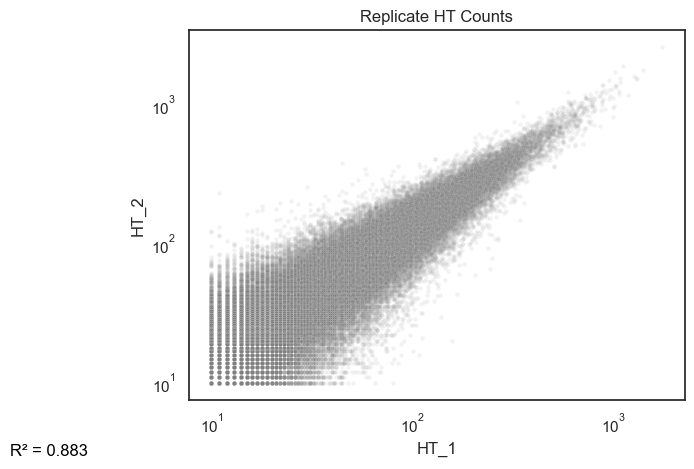

In [13]:
# Specify parameters here
sns.set(style='white')
          
subsets = data[data['Mutation Type'] != 'standard']

x = 'HT_1'
y = 'HT_2'

sns.scatterplot(data=subsets,
                    x=x, y=y, 
                    color="grey", s=10, alpha=0.1)
    
# Set title, labels and limits for each subplot
plt.title('Replicate HT Counts')
# plt.xlim(-500, 7000)
# plt.ylim(-500, 7000)
plt.xscale('log')
plt.yscale('log')
    
# Linear regression statistics for each pair
select = subsets.dropna(subset=[x, y])
slope, intercept, r_value, p_value, std_err = stats.linregress(select[x], select[y])
rsquared = r_value**2
print(f"r-squared = {rsquared:.4f}")    
# print(f'{x} vs {y}: slope = {slope:.4f}, intercept = {intercept:.4f}, r-value = {r_value:.4f}, p-value = {p_value:.4f}')
    
# Add R² to the plot
plt.text(1, 3, f'R² = {rsquared:.3f}', fontsize=12, color='black')

# Save files
plt.savefig(data_storage_path + 'plots/' + experiment_name + '_replicate_HT.png')

# Plots

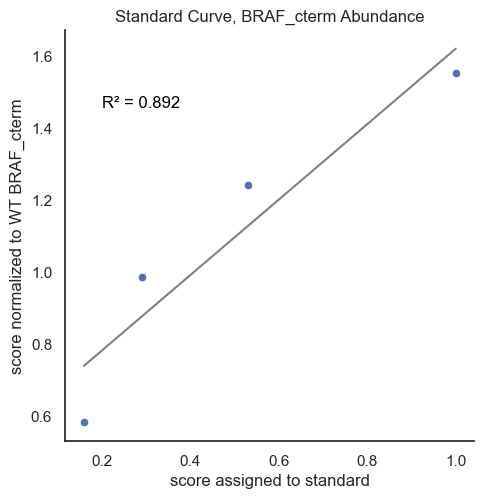

In [14]:
# Plot standard curve
sns.relplot(data=standard_scores, x="Assigned Standard Score", y="average score")

# Recalculate fit based on WT normalized scores, so they're easy to understand
slope, intercept, r_value, p_value, std_err = stats.linregress(standard_scores['Assigned Standard Score'].values, standard_scores['average score'].values)
rsquared = r_value**2


x_vals = np.linspace(standard_scores['Assigned Standard Score'].min(), standard_scores['Assigned Standard Score'].max(), 100) #outputs a numpy array
y_vals = (slope * x_vals) + intercept #performs math on each value in the numpy array, x, and returns a new array
plt.plot(x_vals, y_vals, color='gray') #plot line
plt.title('Standard Curve, ' + library + ' Abundance')
plt.ylabel('score normalized to WT ' + library)
plt.xlabel('score assigned to standard')
plt.text(x_vals.max() * 0.2, y_vals.max() * 0.9, f'R² = {rsquared:.3f}', fontsize=12, color='black')

plt.savefig(data_storage_path + 'plots/' + experiment_name + '_standard_curve.svg')
plt.savefig(data_storage_path + 'plots/' + experiment_name + '_standard_curve.png')

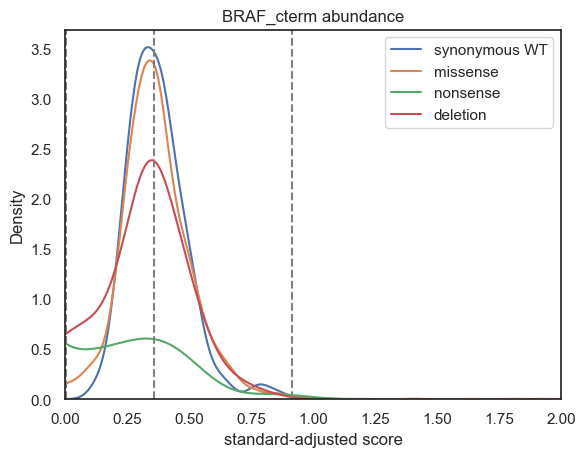

In [15]:
sns.set(style='white')

plt.title(library + ' abundance')

sns.kdeplot(data = Replicate_scores[Replicate_scores['Mutation Type'] == 'synonymous wild type'], x = 'standard-adjusted score', label='synonymous WT')
sns.kdeplot(data = Replicate_scores[Replicate_scores['Mutation Type'] == 'missense'], x = 'standard-adjusted score', label='missense')
sns.kdeplot(data = Replicate_scores[Replicate_scores['Mutation Type'] == 'nonsense'], x = 'standard-adjusted score', label='nonsense')
sns.kdeplot(data = Replicate_scores[Replicate_scores['Mutation Type'] == 'deletion'], x = 'standard-adjusted score', label='deletion')

plt.xlim([0,2])
plt.axvline(x=Replicate_scores[Replicate_scores['variant'] == 'Wild Type_std']['standard-adjusted score'].values[0], color = 'gray', linestyle = 'dashed')
# plt.axvline(x=Replicate_scores[Replicate_scores['variant'] == 'P367N_std']['standard-adjusted score'].values[0], color = 'gray', linestyle = 'dashed')
plt.axvline(x=Replicate_scores[Replicate_scores['variant'] == 'I592S_std']['standard-adjusted score'].values[0], color = 'gray', linestyle = 'dashed')
# plt.axvline(x=Replicate_scores[Replicate_scores['variant'] == 'G258N_std']['standard-adjusted score'].values[0], color = 'gray', linestyle = 'dashed')
plt.axvline(x=Replicate_scores[Replicate_scores['variant'] == 'E695*_std']['standard-adjusted score'].values[0], color = 'gray', linestyle = 'dashed')

plt.legend()

plt.savefig(data_storage_path + 'plots/' + experiment_name + '_distributions_normalized_to_standards.svg')
plt.savefig(data_storage_path + 'plots/' + experiment_name + '_distributions_normalized_to_standards.png')

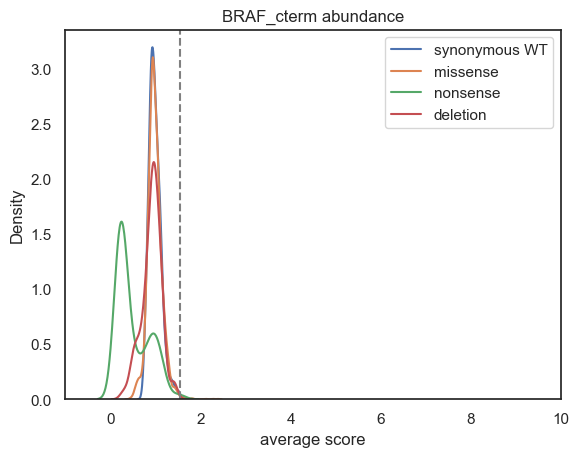

In [16]:
sns.set(style='white')

plt.title(library + ' abundance')

sns.kdeplot(data = Replicate_scores[Replicate_scores['Mutation Type'] == 'synonymous wild type'], x = 'average score', label='synonymous WT')
sns.kdeplot(data = Replicate_scores[Replicate_scores['Mutation Type'] == 'missense'], x = 'average score', label='missense')
sns.kdeplot(data = Replicate_scores[Replicate_scores['Mutation Type'] == 'nonsense'], x = 'average score', label='nonsense')
sns.kdeplot(data = Replicate_scores[Replicate_scores['Mutation Type'] == 'deletion'], x = 'average score', label='deletion')

plt.xlim([-1,10])
plt.axvline(x=Replicate_scores[Replicate_scores['variant'] == 'Wild Type_std']['average score'].values[0], color = 'gray', linestyle = 'dashed')
# plt.axvline(x=Replicate_scores[Replicate_scores['variant'] == 'G469T_std']['average score'].values[0], color = 'gray', linestyle = 'dashed')
# plt.axvline(x=Replicate_scores[Replicate_scores['variant'] == 'G258E_std']['average score'].values[0], color = 'gray', linestyle = 'dashed')
# plt.axvline(x=Replicate_scores[Replicate_scores['variant'] == 'K601D_std']['average score'].values[0], color = 'gray', linestyle = 'dashed')
# plt.axvline(x=Replicate_scores[Replicate_scores['variant'] == 'R509Y_std']['average score'].values[0], color = 'gray', linestyle = 'dashed')

plt.legend()

plt.savefig(data_storage_path + 'plots/' + experiment_name + '_distributions.svg')
plt.savefig(data_storage_path + 'plots/' + experiment_name + '_distributions.png')

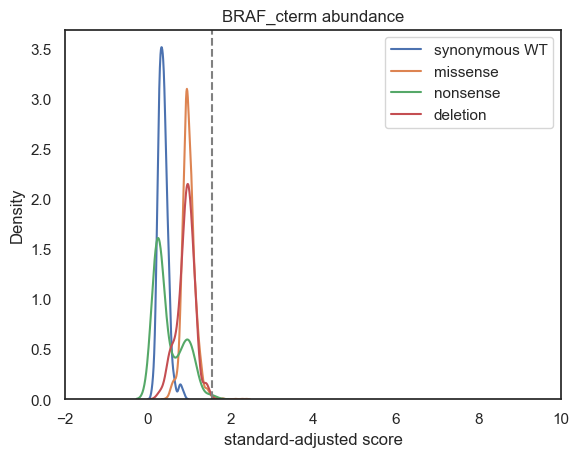

In [17]:
sns.set(style='white')

plt.title(library + ' abundance')

sns.kdeplot(data = Replicate_scores[Replicate_scores['Mutation Type'] == 'synonymous wild type'], x = 'standard-adjusted score', label='synonymous WT')
sns.kdeplot(data = Replicate_scores[Replicate_scores['Mutation Type'] == 'missense'], x = 'average score', label='missense')
sns.kdeplot(data = Replicate_scores[Replicate_scores['Mutation Type'] == 'nonsense'], x = 'average score', label='nonsense')
sns.kdeplot(data = Replicate_scores[Replicate_scores['Mutation Type'] == 'deletion'], x = 'average score', label='deletion')

plt.xlim([-2,10])
plt.axvline(x=Replicate_scores[Replicate_scores['variant'] == 'Wild Type_std']['average score'].values[0], color = 'gray', linestyle = 'dashed')
# plt.axvline(x=Replicate_scores[Replicate_scores['variant'] == 'G469T_std']['average score'].values[0], color = 'gray', linestyle = 'dashed')
# plt.axvline(x=Replicate_scores[Replicate_scores['variant'] == 'G258E_std']['average score'].values[0], color = 'gray', linestyle = 'dashed')
# plt.axvline(x=Replicate_scores[Replicate_scores['variant'] == 'K601D_std']['average score'].values[0], color = 'gray', linestyle = 'dashed')
# plt.axvline(x=Replicate_scores[Replicate_scores['variant'] == 'R509Y_std']['average score'].values[0], color = 'gray', linestyle = 'dashed')

plt.legend()

plt.savefig(data_storage_path + 'plots/' + experiment_name + '_distributions.svg')
plt.savefig(data_storage_path + 'plots/' + experiment_name + '_distributions.png')

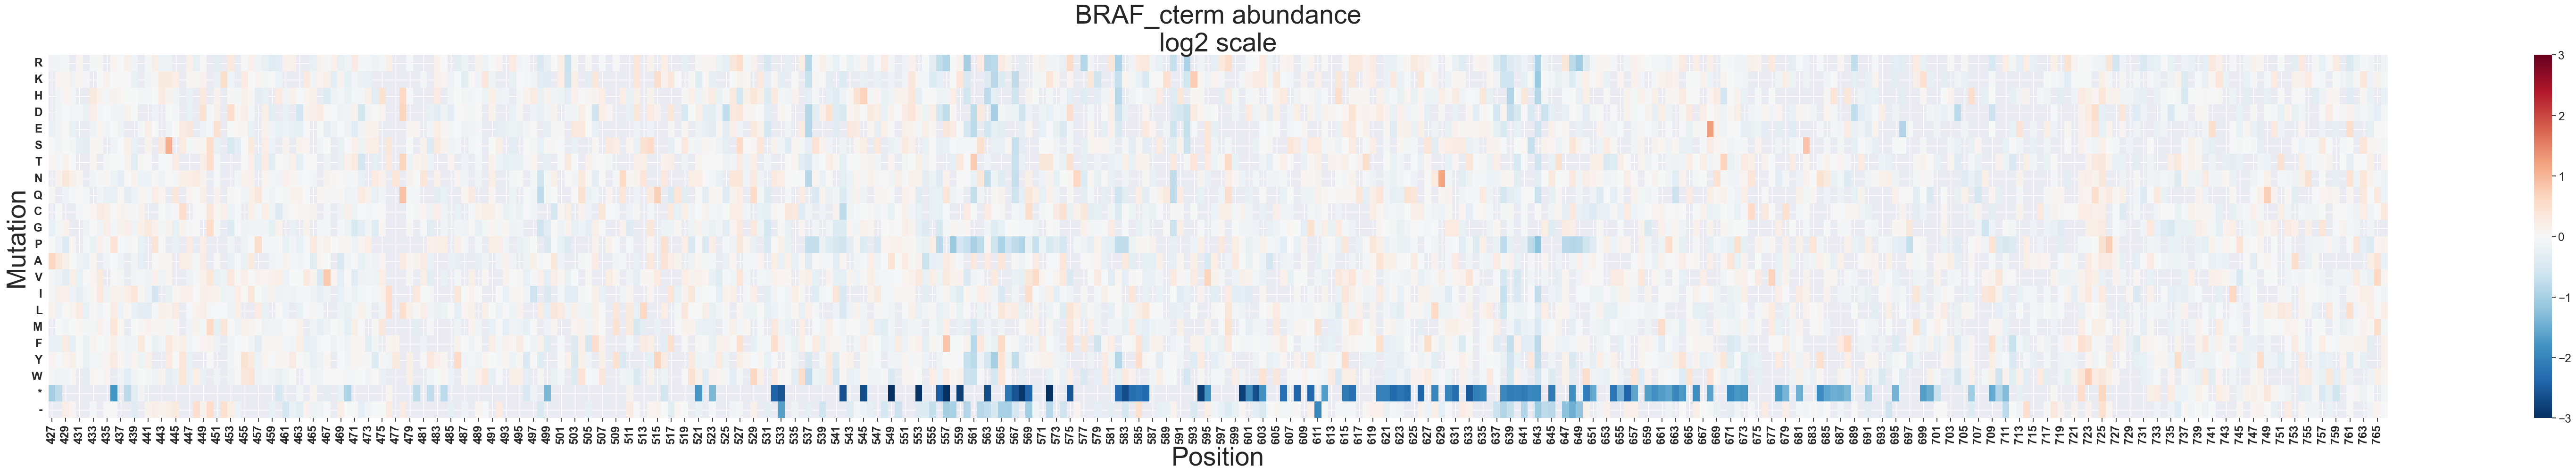

In [18]:
subset = Replicate_scores.copy()
subset['Position'] = pd.to_numeric(subset['Position'], errors='coerce')
max_position = subset['Position'].max()

heatmap_from_ReplicateScores('average score', -3, 3, 0, library + ' abundance' + '\n' + 'log2 scale', 'log2', 1, max_position)

plt.savefig(data_storage_path + 'plots/' + experiment_name + '_heatmap.svg')
plt.savefig(data_storage_path + 'plots/' + experiment_name + '_heatmap.png')

# Pymol Tables

In [19]:
# Group by 'Position' and average the score

subset = Replicate_scores.copy()
subset = subset[(subset['Position']!='standard') & (subset['Position']!='wild type') & (subset['Position']!=1) & (subset['Mutation Type']!='nonsense') & (subset['Mutation Type']!='deletion') & (subset['Mutation Type']!='frameshift')]
subset = subset.groupby(['Position'])['average score'].mean().reset_index()
subset.to_csv(data_storage_path + library + '_abundance.tsv', index=False, header=False, sep='\t')
subset.to_csv(data_storage_path + 'pymol_files/' + experiment_name + '_pymol_position_averaged_scores.tsv', index=False, header=False, sep='\t')

subset

,Position,average score
0,427,1.005987
1,428,0.972479
2,429,1.014463
3,430,0.984702
4,431,0.977287
...,...,...
335,762,1.004469
336,763,1.070247
337,764,0.961700
338,765,1.106316


In [20]:
# Group by 'Position' and average the score

subset = Replicate_scores.copy()
subset = subset[(subset['Position']!='standard') & (subset['Position']!='wild type') & (subset['Position']!=1) & (subset['Mutation Type']!='nonsense') & (subset['Mutation Type']!='deletion') & (subset['Mutation Type']!='frameshift')]
subset = subset.groupby(['Position'])['average score'].mean().reset_index()
subset['average score'] = np.log(subset['average score'])
subset = subset.dropna()
subset.to_csv(data_storage_path + library + '_abundance_logscale.tsv', index=False, header=False, sep='\t')
subset.to_csv(data_storage_path + 'pymol_files/' + experiment_name + '_pymol_position_averaged_scores_logscale.tsv', index=False, header=False, sep='\t')

subset

,Position,average score
0,427,0.005969
1,428,-0.027907
2,429,0.014359
3,430,-0.015417
4,431,-0.022975
...,...,...
335,762,0.004459
336,763,0.067889
337,764,-0.039053
338,765,0.101036


# Bias check

r-squared = 0.0496


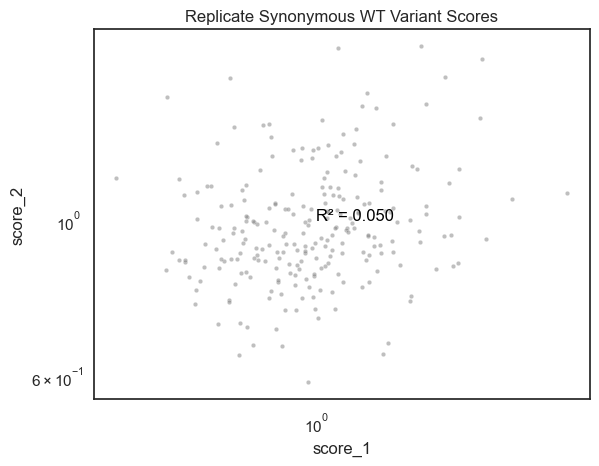

In [21]:
# Specify parameters here
sns.set(style='white')
          
subsets = Replicate_scores[Replicate_scores['Mutation Type'] == 'synonymous wild type']

x = 'score_1'
y = 'score_2'

sns.scatterplot(data=subsets,
                    x=x, y=y, 
                    color="grey", s=10, alpha=0.5)
    
# Set title, labels and limits for each subplot
plt.title('Replicate Synonymous WT Variant Scores')
# plt.xlim(-500, 7000)
# plt.ylim(-500, 7000)
plt.xscale('log')
plt.yscale('log')
    
# Linear regression statistics for each pair
select = subsets.dropna(subset=[x, y])
slope, intercept, r_value, p_value, std_err = stats.linregress(select[x], select[y])
rsquared = r_value**2
print(f"r-squared = {rsquared:.4f}")    
# print(f'{x} vs {y}: slope = {slope:.4f}, intercept = {intercept:.4f}, r-value = {r_value:.4f}, p-value = {p_value:.4f}')
    
# Add R² to the plot
plt.text(1, 1, f'R² = {rsquared:.3f}', fontsize=12, color='black')

# Save files
plt.savefig(data_storage_path + 'plots/' + experiment_name + '_bias_check.png')

# Additional Analyses

/var/folders/fg/m93kmv592kqbmp6mmglyp4_c0000gn/T/ipykernel_24880/3207311695.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, '# variants')

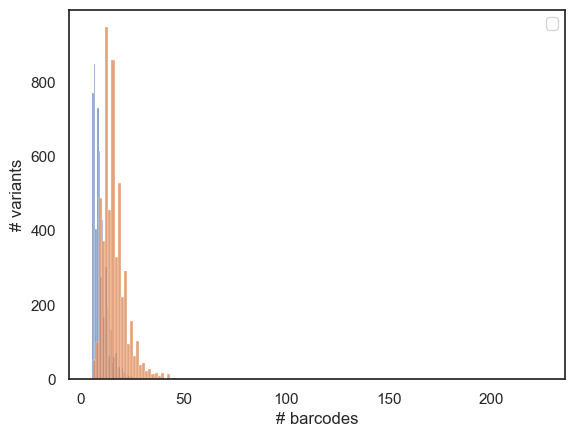

In [22]:
sns.histplot(data=Replicate_scores['average_num_quant_bc'], legend = 'average number of quantified barcodes per replicate')
sns.histplot(data=Replicate_scores['Number of Barcodes'], legend = 'total number barcodes observed across all replicates')

plt.legend()
plt.xlabel('# barcodes')
plt.ylabel('# variants')

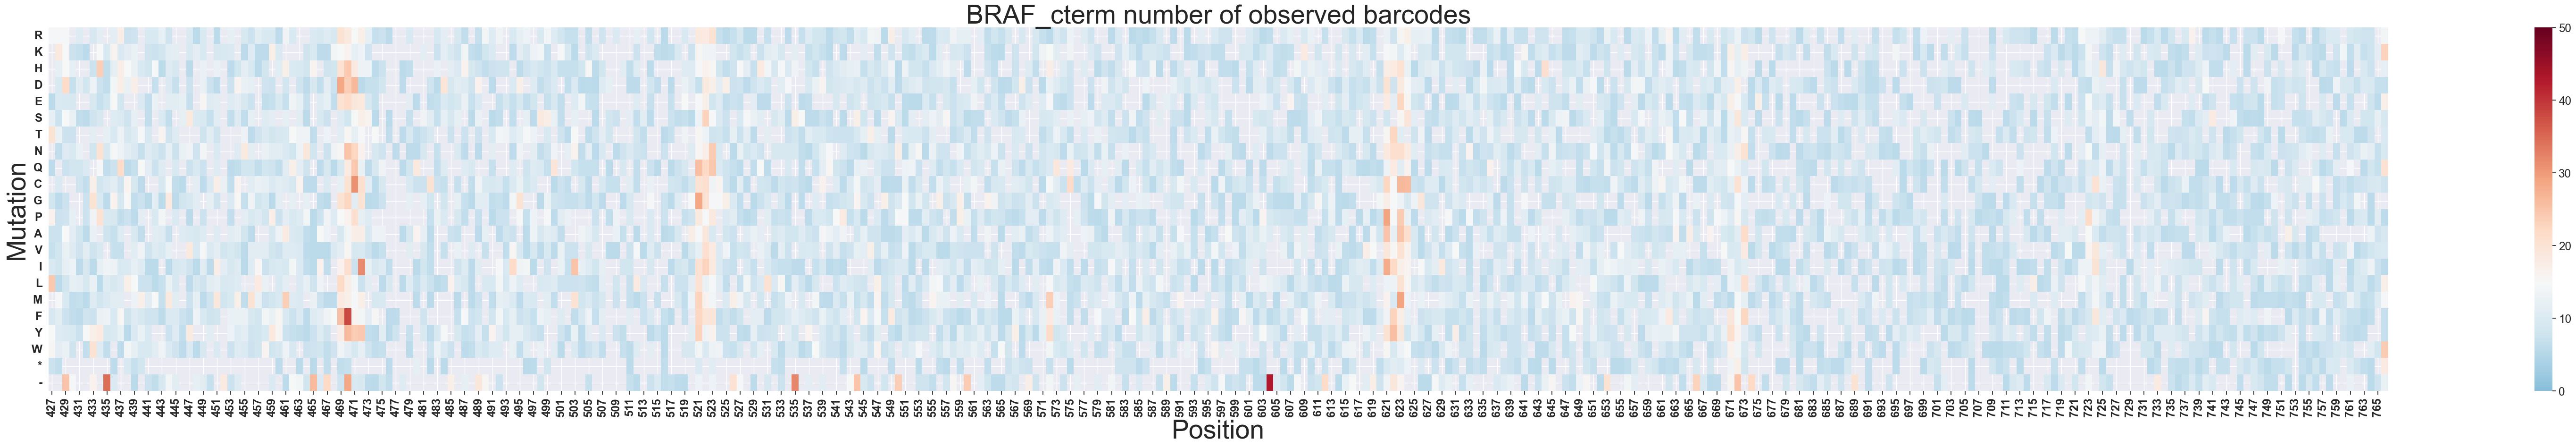

In [23]:
subset = Replicate_scores.copy()
subset['Position'] = pd.to_numeric(subset['Position'], errors='coerce')
max_position = subset['Position'].max()

heatmap_from_ReplicateScores('average_num_quant_bc', 0, 50, Replicate_scores['Number of Barcodes'].median(), library + ' number of observed barcodes', 'linear', 1, max_position)
